In [2]:
import pandas as pd
from pathlib import Path

# Define the project folder (same folder as notebook)
project_folder = Path(".")  # current folder

# Load datasets from the same folder
train = pd.read_csv(project_folder / "gold_recovery_train.csv", parse_dates=['date'])
test = pd.read_csv(project_folder / "gold_recovery_test.csv", parse_dates=['date'])
full = pd.read_csv(project_folder / "gold_recovery_full.csv", parse_dates=['date'])

# Display general information about each dataset
print(train.info())
print(test.info())
print(full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                16860 non-null  datetime64[ns]
 1   final.output.concentrate_ag                         16788 non-null  float64       
 2   final.output.concentrate_pb                         16788 non-null  float64       
 3   final.output.concentrate_sol                        16490 non-null  float64       
 4   final.output.concentrate_au                         16789 non-null  float64       
 5   final.output.recovery                               15339 non-null  float64       
 6   final.output.tail_ag                                16794 non-null  float64       
 7   final.output.tail_pb                                16677 non-null  float64       
 8   final.

### Data Structure

After loading and inspecting the datasets, it is observed that the training set contains a larger number of variables compared to the test set. This difference is expected, as some variables in the training dataset correspond to output parameters or calculations that are not available at the time of making predictions.

To ensure consistency between the training and test sets—and to prevent data leakage—the training dataset will be restricted to only those variables that are also present in the test set. This way, the model is trained exclusively with information that would be available in a real-world scenario.

### Handling Missing Values

During preliminary analysis, missing values were identified in multiple variables within the dataset. Since these values can negatively impact model performance and stability, they need to be addressed during preprocessing.

To tackle this issue, missing values will be imputed using forward fill (ffill), which is preferred over median imputation because the data are temporal and derived from industrial processes.

### Summary of Preprocessing Steps

- Align training set variables with test set variables to prevent data leakage  
- Remove unavailable variables or those derived from future information  
- Impute missing values using forward fill for temporal consistency  

In [104]:

import numpy as np

def recovery_calc(C, F, T):
    return (C * (F - T)) / (F * (C - T)) * 100

calc = recovery_calc(
    train['rougher.output.concentrate_au'],
    train['rougher.input.feed_au'],
    train['rougher.output.tail_au']
)

mae = np.mean(abs(calc - train['rougher.output.recovery']))
print(mae)


9.303415616264301e-15


In [ ]:
# Sort datasets by date to ensure forward fill is applied correctly
train = train.sort_values('date').reset_index(drop=True)
test = test.sort_values('date').reset_index(drop=True)
full = full.sort_values('date').reset_index(drop=True)

# Impute missing values using forward fill (ffill)
train = train.ffill()
test = test.ffill()
full = full.ffill()

The Mean Absolute Error (MAE) between the calculated recovery values and those provided in the dataset is extremely low (≈ 9.3e-15), indicating that the formula has been implemented correctly and that the data are consistent.

The small observed difference is due to numerical precision limitations inherent to floating-point calculations and can therefore be considered negligible.

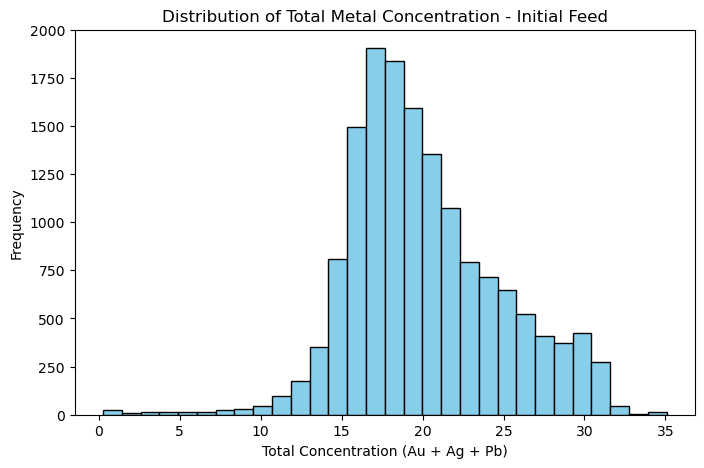

In [3]:
import matplotlib.pyplot as plt
# Calculate total metal concentration in the feed
total_feed = (
    train['rougher.input.feed_au'] +
    train['rougher.input.feed_ag'] +
    train['rougher.input.feed_pb']
)

# Filter out near-zero values
total_feed_filtered = total_feed[total_feed > 0.1]

# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(total_feed_filtered, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Metal Concentration - Initial Feed')
plt.xlabel('Total Concentration (Au + Ag + Pb)')
plt.ylabel('Frequency')
plt.show()

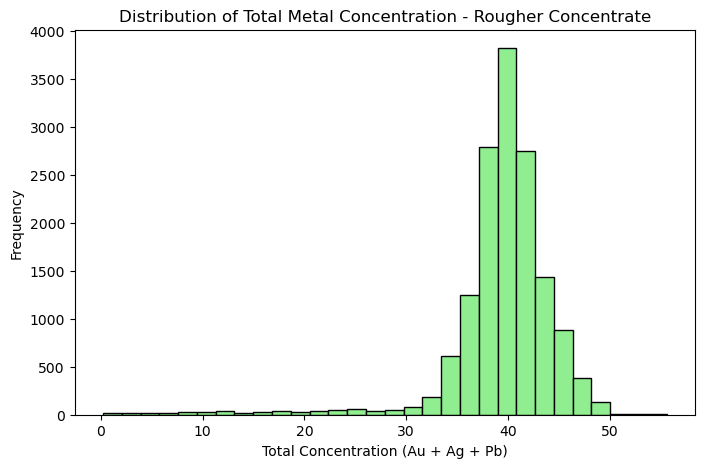

In [4]:
# Calculate total metal concentration in the rougher concentrate
rougher_cols = [
    'rougher.output.concentrate_au',
    'rougher.output.concentrate_ag',
    'rougher.output.concentrate_pb'
]

# Select only columns that exist in the training set to avoid KeyError
existing_cols = [col for col in rougher_cols if col in train.columns]

total_rougher = train[existing_cols].sum(axis=1)

# Filter out near-zero values
total_rougher_filtered = total_rougher[total_rougher > 0.1]

# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(total_rougher_filtered, bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Total Metal Concentration - Rougher Concentrate')
plt.xlabel('Total Concentration (Au + Ag + Pb)')
plt.ylabel('Frequency')
plt.show()

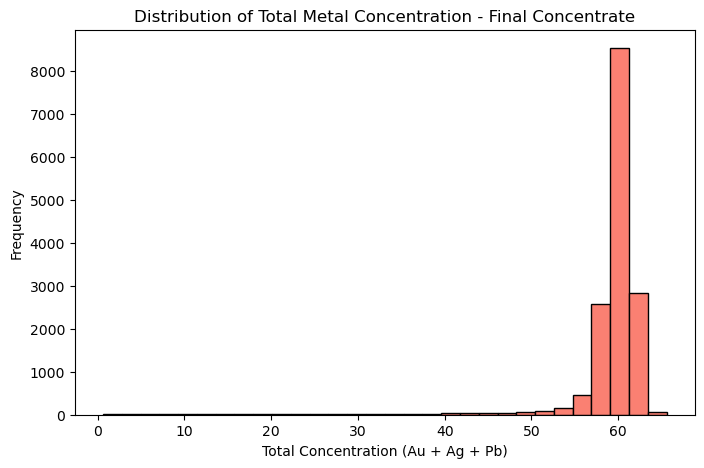

In [5]:
# Calculate total metal concentration in the final concentrate
total_final = (
    train['final.output.concentrate_au'] +
    train['final.output.concentrate_ag'] +
    train['final.output.concentrate_pb']
)

# Filter out near-zero values
total_final_filtered = total_final[total_final > 0.1]

# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(total_final_filtered, bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of Total Metal Concentration - Final Concentrate')
plt.xlabel('Total Concentration (Au + Ag + Pb)')
plt.ylabel('Frequency')
plt.show()


Near-zero values (below 0.1) were removed from the distribution as they were considered anomalies.

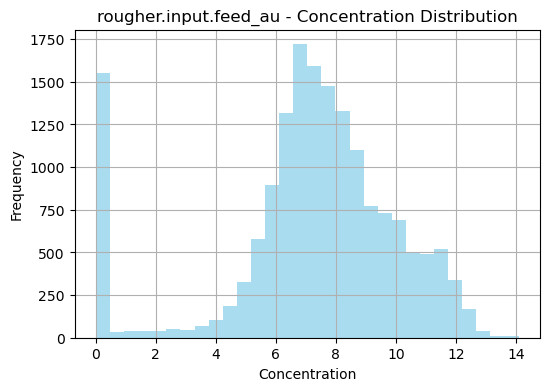

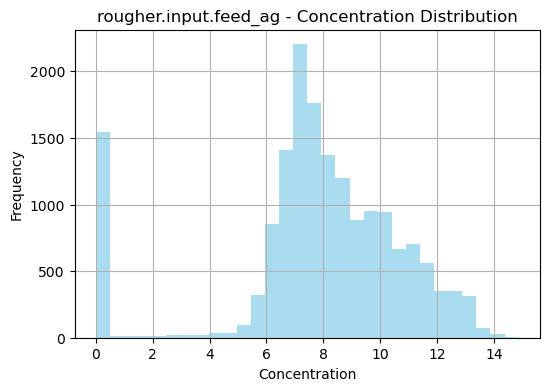

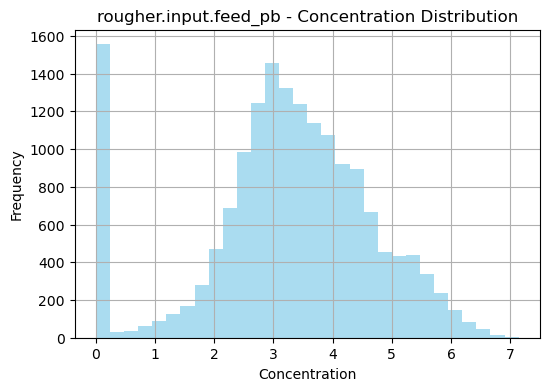

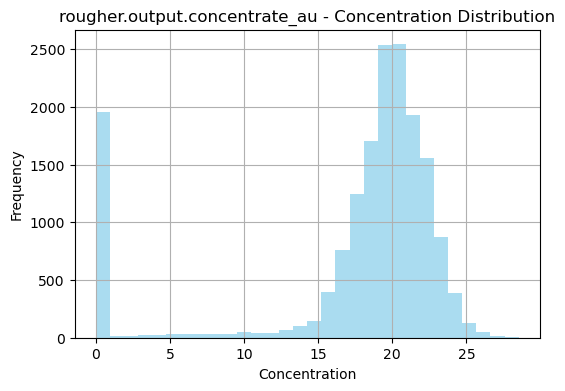

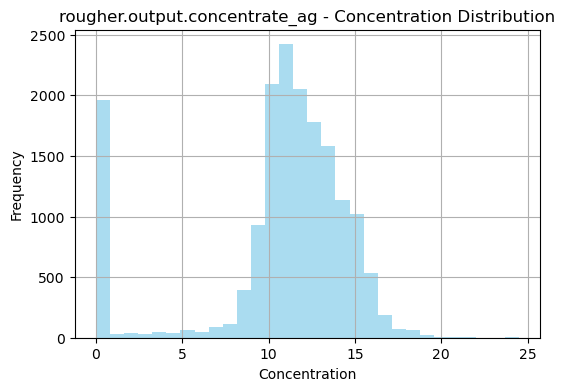

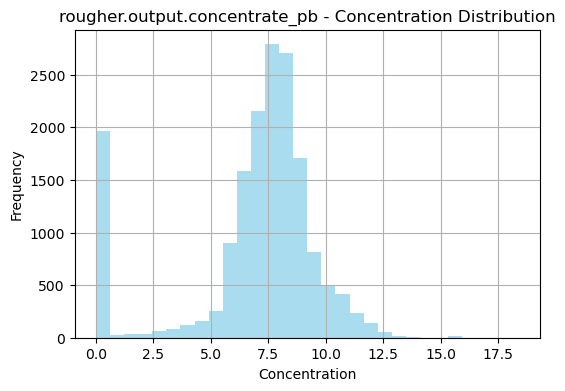

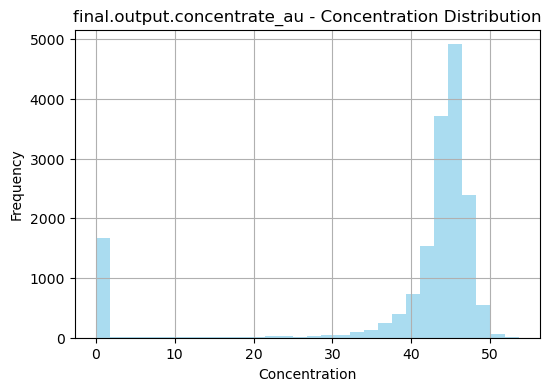

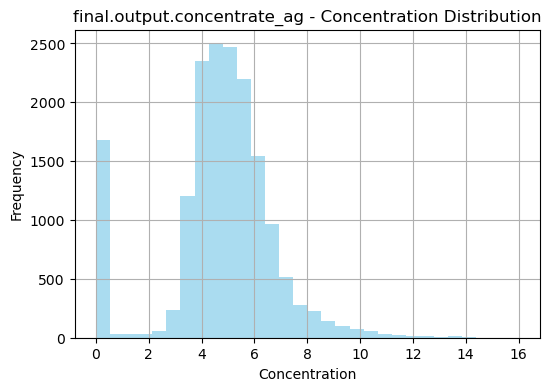

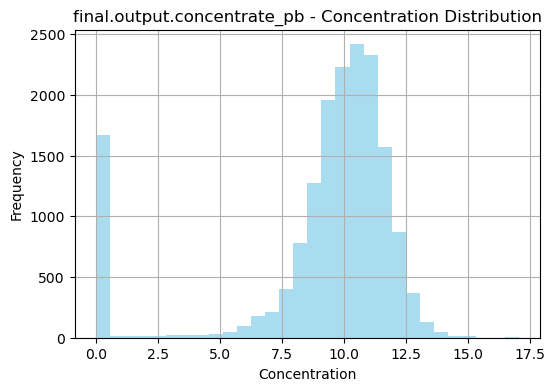

In [6]:
# Metals and processing stages
metals = ['au', 'ag', 'pb']
stages = ['rougher.input.feed', 'rougher.output.concentrate', 'final.output.concentrate']

# Iterate and plot distributions
for stage in stages:
    for metal in metals:
        col = f'{stage}_{metal}'
        plt.figure(figsize=(6, 4))
        train[col].hist(bins=30, alpha=0.7, color='skyblue')
        plt.title(f'{col} - Concentration Distribution')
        plt.xlabel('Concentration')
        plt.ylabel('Frequency')
        plt.show()


## Discussion: Changes in Metal Concentration Across Purification Stages

The distributions of gold (Au), silver (Ag), and lead (Pb) concentrations were analyzed across the different stages of the flotation and purification process. The results illustrate how the industrial process impacts the concentration of each metal.

### Gold (Au)

- **Initial feed (rougher.input.feed_au):**  
  Range: 4 to 12 | Peak frequency: ~1700  
  Represents the gold concentration in the raw material, showing low concentration and moderate variability.

- **Post-flotation concentrate (rougher.output.concentrate_au):**  
  Range: 15 to 25 | Peak frequency: ~2500  
  A significant increase is observed, reflecting the effective separation of gold from the waste material (*rougher tails*).

- **Final concentrate after purification (final.output.concentrate_au):**  
  Range: 40 to 50 | Peak frequency: ~5000  
  The concentration reaches its highest level, indicating that the final purification stage efficiently and consistently concentrates the remaining gold.

---

### Silver (Ag)

- **Initial feed (rougher.input.feed_ag):**  
  Range: 6 to 13 | Peak frequency: ~2100  
  The initial concentration is moderate, with a relatively wide distribution.

- **Post-flotation concentrate (rougher.output.concentrate_ag):**  
  Range: 9 to 16 | Peak frequency: ~2400  
  A slight increase is observed, indicating that flotation partially concentrates silver along with gold.

- **Final concentrate after purification (final.output.concentrate_ag):**  
  Range: 3 to 8 | Peak frequency: ~2500  
  Interestingly, the final concentration decreases, suggesting that the purification process is designed to maximize gold recovery and may remove part of the silver as a byproduct.

---

### Lead (Pb)

- **Initial feed (rougher.input.feed_pb):**  
  Range: 2 to 6 | Peak frequency: ~1400  
  The initial lead concentration is low, reflecting its limited presence in the raw material.
  
- - **Post-flotation concentrate (rougher.output.concentrate_pb):**  
  Range: 5 to 10 | Peak frequency: ~2700  
  An increase is observed, indicating that part of the lead is also concentrated during the flotation stage.

- **Final concentrate after purification (final.output.concentrate_pb):**  
  Range: 7.5 to 12 | Peak frequency: ~2400  
  The final lead concentration continues to increase, although with a lower peak frequency than in the intermediate stage, reflecting a purification process that retains some lead while prioritizing gold extraction.

---

### Overall Conclusion

- Gold (Au) shows a **steady progressive increase**, aligned with the main objective of the purification process.  
- Silver (Ag) and lead (Pb) exhibit different behaviors: silver decreases in the final stage, while lead increases moderately, reflecting the process selectivity toward gold recovery.  
- Peak frequencies indicate that most samples are concentrated within specific ranges, suggesting **stability and consistency** in the operation of the industrial plant.


In [7]:
# Save target variables before dropping columns
target_rougher = train['rougher.output.recovery'].copy()
target_final = train['final.output.recovery'].copy()

# Identify columns present in train but NOT in test
missing_cols = list(set(train.columns) - set(test.columns))
print("Columns to drop to prevent data leakage:", missing_cols)

# Create a safe feature set
# Drop columns in missing_cols to avoid using future information
features = train.drop(columns=missing_cols)

# Check shapes
print("Features shape:", features.shape)
print("target_rougher shape:", target_rougher.shape)
print("target_final shape:", target_final.shape)

Columns to drop to prevent data leakage: ['rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.output.tail_au', 'final.output.tail_ag', 'rougher.calculation.au_pb_ratio', 'primary_cleaner.output.tail_sol', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.tail_ag', 'secondary_cleaner.output.tail_ag', 'final.output.concentrate_ag', 'primary_cleaner.output.concentrate_ag', 'rougher.calculation.sulfate_to_au_concentrate', 'final.output.concentrate_sol', 'secondary_cleaner.output.tail_au', 'rougher.output.concentrate_au', 'rougher.output.tail_pb', 'primary_cleaner.output.concentrate_pb', 'secondary_cleaner.output.tail_pb', 'final.output.recovery', 'final.output.tail_au', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.concentrate_au', 'rougher.output.recovery', 'final.output.tail_sol', 'rougher.output.concentrate_ag', 'final.output.concentrate_au', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'primary_cleaner.output.tail_au', 'rougher.output.con

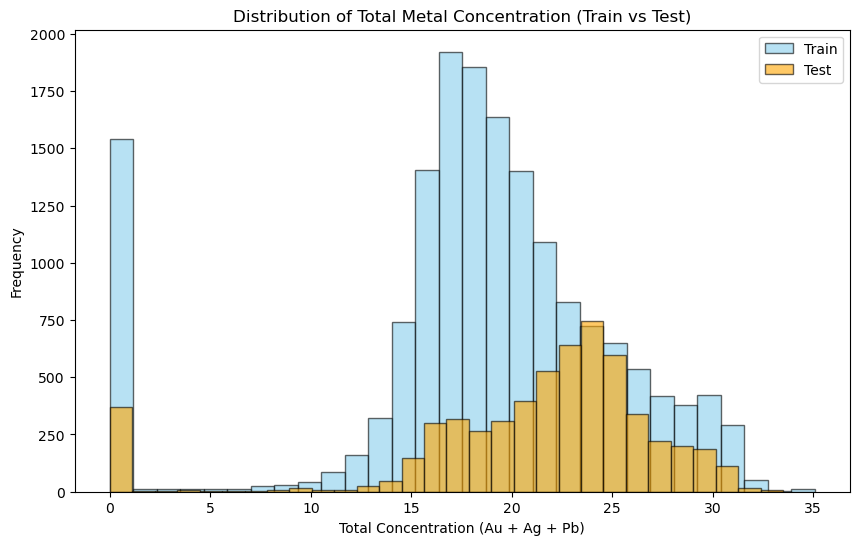

In [8]:
# Calculate total metal concentration for train and test sets
total_train = (
    train['rougher.input.feed_au'] +
    train['rougher.input.feed_ag'] +
    train['rougher.input.feed_pb']
)

total_test = (
    test['rougher.input.feed_au'] +
    test['rougher.input.feed_ag'] +
    test['rougher.input.feed_pb']
)

# Plot both histograms on the same figure
plt.figure(figsize=(10, 6))
plt.hist(total_train, bins=30, alpha=0.6, label='Train', color='skyblue', edgecolor='black')
plt.hist(total_test, bins=30, alpha=0.6, label='Test', color='orange', edgecolor='black')
plt.title('Distribution of Total Metal Concentration (Train vs Test)')
plt.xlabel('Total Concentration (Au + Ag + Pb)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

The histogram of total metal concentration shows that the value ranges in the training and test sets are **similar**, indicating that the model will be able to generalize across the same intervals. Although the observation frequencies differ, this does not affect model evaluation, as the variable ranges remain consistent.

In [16]:
print(target_rougher.isna().sum())
print(target_final.isna().sum())

2573
1521


In [25]:
# -------------------------------
# Create consistent features and targets
# -------------------------------
df_train_temp = features.copy()
df_train_temp['target_rougher'] = target_rougher
df_train_temp['target_final'] = target_final

# Drop rows where any target is missing
df_train_temp = df_train_temp.dropna(subset=['target_rougher', 'target_final'])

# Separate features and targets again
features_clean = df_train_temp.drop(columns=['target_rougher', 'target_final'])
target_rougher_clean = df_train_temp['target_rougher']
target_final_clean = df_train_temp['target_final']

In [24]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict

# Safe sMAPE function
def smape(y_true, y_pred):
    denominator = np.abs(y_true) + np.abs(y_pred)
    denominator = np.maximum(denominator, 1e-9)  # avoid division by zero
    diff = np.abs(y_true - y_pred) / denominator
    return 100 * np.mean(diff)

# Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=123, n_jobs=-1)

# Predictions using simple CV (5 folds)
pred_rougher = cross_val_predict(rf_model, features_clean, target_rougher_clean, cv=5)
pred_final = cross_val_predict(rf_model, features_clean, target_final_clean, cv=5)

# Compute sMAPE
smape_rougher = smape(target_rougher_clean, pred_rougher)
smape_final = smape(target_final_clean, pred_final)
smape_total = 0.25 * smape_rougher + 0.75 * smape_final

print(f"sMAPE Rougher: {smape_rougher:.4f}%")
print(f"sMAPE Final: {smape_final:.4f}%")
print(f"Combined sMAPE: {smape_total:.4f}%")

sMAPE Rougher: 7.0557%
sMAPE Final: 5.6216%
Combined sMAPE: 5.9801%


## Gold Recovery Prediction Model Conclusions

After training and evaluating the **Random Forest** model to predict gold recovery at different stages of the process, the following results were obtained:

- **Rougher sMAPE:** 7.06 %  
- **Final sMAPE:** 5.62 %  
- **Combined Total sMAPE:** 5.98 %  

### Key Insights

1. **Better performance in the final stage:**  
   The model predicts gold recovery more accurately in the final purification stage, as indicated by a lower sMAPE (5.62 %) compared to the Rougher stage (7.06 %).  

2. **Strong overall accuracy:**  
   The combined total sMAPE of 5.98 % reflects solid model performance in capturing trends of gold recovery, considering that the final stage carries more weight in the combined metric.  

3. **Opportunities for improvement:**  
   While the model demonstrates good precision, predictions for the Rougher stage could be further optimized through hyperparameter tuning or exploring alternative machine learning algorithms.  

**Summary:**  
The model provides reliable predictions for monitoring and controlling the gold recovery process, with a low relative error that is slightly more critical in the Rougher stage than in the final stage.